In [2]:
import igraph as ig
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# параметры варианта

n = 60

er_p = 0.07
ba_m = 1

ws_k = 4
ws_p = 0.05

In [4]:
# генерация графов

er_graph = ig.Graph.Erdos_Renyi(n=n, p=er_p)

ba_graph = ig.Graph.Barabasi(n=n, m=ba_m)

ws_graph = ig.Graph.Watts_Strogatz(
    dim=1,
    size=n,
    nei=ws_k // 2,
    p=ws_p
)

print("Графы успешно созданы")

Графы успешно созданы


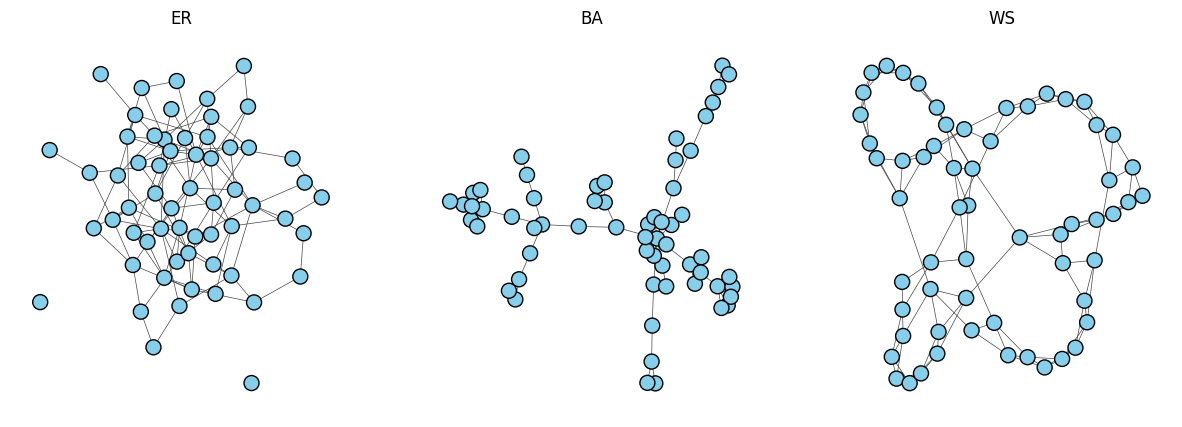

In [5]:
layout = "fr"

fig, axes = plt.subplots(1,3, figsize=(15,5))

graphs = [
    ("ER", er_graph),
    ("BA", ba_graph),
    ("WS", ws_graph)
]

for ax, (name, graph) in zip(axes, graphs):

    ig.plot(
        graph,
        target=ax,
        layout=layout,
        vertex_size=15,
        vertex_color="skyblue",
        edge_width=0.5
    )

    ax.set_title(name)

plt.show()

In [6]:
def analyze_graph(graph):

    degrees = graph.degree()

    avg_clustering = graph.transitivity_avglocal_undirected()
    global_clustering = graph.transitivity_undirected()

    diameter = graph.diameter()

    avg_path_length = graph.average_path_length()

    density = graph.density()

    components = graph.components()

    num_components = len(components)

    giant_component_size = components.giant().vcount()

    return {
        "degrees": degrees,
        "avg_clustering": avg_clustering,
        "global_clustering": global_clustering,
        "diameter": diameter,
        "avg_path_length": avg_path_length,
        "density": density,
        "components": num_components,
        "giant_component": giant_component_size
    }

In [7]:
results = {}

results["ER"] = analyze_graph(er_graph)
results["BA"] = analyze_graph(ba_graph)
results["WS"] = analyze_graph(ws_graph)

results

{'ER': {'degrees': [5,
   4,
   2,
   4,
   5,
   4,
   3,
   3,
   2,
   1,
   5,
   3,
   2,
   3,
   2,
   7,
   2,
   3,
   3,
   7,
   3,
   2,
   6,
   5,
   4,
   5,
   3,
   5,
   5,
   4,
   5,
   5,
   6,
   4,
   3,
   5,
   8,
   2,
   3,
   3,
   3,
   3,
   3,
   3,
   1,
   5,
   0,
   5,
   3,
   2,
   4,
   5,
   7,
   0,
   5,
   2,
   5,
   6,
   3,
   1],
  'avg_clustering': 0.04445887445887446,
  'global_clustering': 0.05412371134020618,
  'diameter': 6,
  'avg_path_length': 3.0477918935269206,
  'density': 0.06271186440677966,
  'components': 3,
  'giant_component': 58},
 'BA': {'degrees': [3,
   2,
   13,
   2,
   3,
   5,
   2,
   5,
   2,
   4,
   1,
   2,
   7,
   2,
   2,
   1,
   1,
   1,
   1,
   3,
   3,
   6,
   1,
   1,
   1,
   2,
   2,
   1,
   1,
   1,
   3,
   1,
   1,
   1,
   1,
   1,
   1,
   2,
   2,
   1,
   1,
   1,
   1,
   1,
   1,
   3,
   1,
   1,
   1,
   1,
   1,
   2,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1],
  'avg_clustering': 0

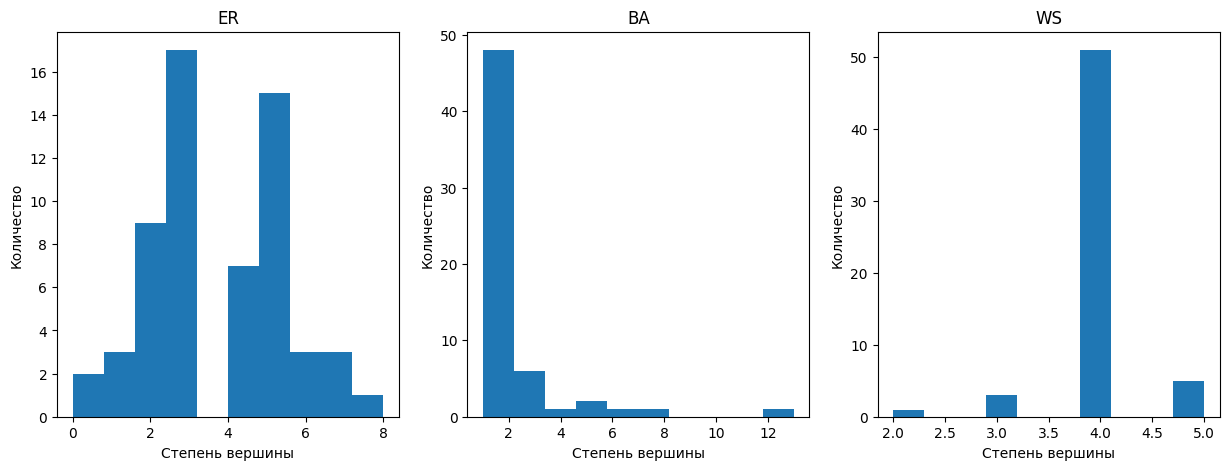

In [8]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

for ax, name in zip(axes, results):

    degrees = results[name]["degrees"]

    ax.hist(degrees, bins=10)

    ax.set_title(name)
    ax.set_xlabel("Степень вершины")
    ax.set_ylabel("Количество")

plt.show()

In [9]:
table = []

for name in results:

    r = results[name]

    table.append([
        name,
        r["avg_clustering"],
        r["global_clustering"],
        r["diameter"],
        r["avg_path_length"],
        r["density"],
        r["components"],
        r["giant_component"]
    ])


df = pd.DataFrame(table, columns=[
    "Graph",
    "Avg clustering",
    "Global clustering",
    "Diameter",
    "Avg path length",
    "Density",
    "Components",
    "Giant component"
])

df

,Graph,Avg clustering,Global clustering,Diameter,Avg path length,Density,Components,Giant component
0,ER,0.044459,0.054124,6,3.047792,0.062712,3,58
1,BA,0.000000,0.000000,12,5.362147,0.033333,1,60
2,WS,0.437778,0.418033,9,4.341243,0.067797,1,60


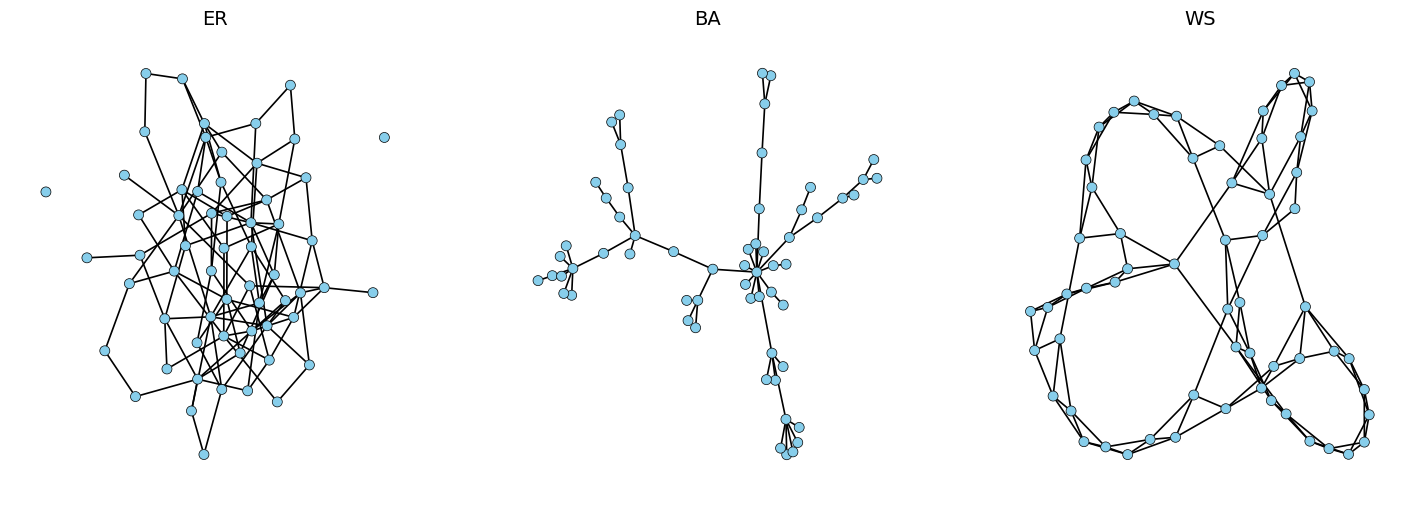

In [10]:
layout_er = er_graph.layout("fr")
layout_ba = ba_graph.layout("fr")
layout_ws = ws_graph.layout("fr")

fig, axes = plt.subplots(1, 3, figsize=(18,6))

graphs = [
    ("ER", er_graph, layout_er),
    ("BA", ba_graph, layout_ba),
    ("WS", ws_graph, layout_ws)
]

for ax, (name, graph, layout) in zip(axes, graphs):

    ig.plot(
        graph,
        target=ax,
        layout=layout,
        vertex_size=10,
        vertex_color="skyblue",
        vertex_frame_width=0.5,
        edge_width=1.2,
        edge_color="black"
    )

    ax.set_title(name, fontsize=14)

plt.show()

In [12]:
exp_results = []

# ER
for p in [0.03, 0.07, 0.15]:
    g = ig.Graph.Erdos_Renyi(n=60, p=p)

    exp_results.append([
        "ER",
        f"p={p}",
        g.density(),
        g.average_path_length(),
        g.transitivity_avglocal_undirected()
    ])

# BA
for m in [1, 2, 3]:
    g = ig.Graph.Barabasi(n=60, m=m)

    exp_results.append([
        "BA",
        f"m={m}",
        g.density(),
        g.average_path_length(),
        g.transitivity_avglocal_undirected()
    ])

# WS
for p in [0.01, 0.05, 0.2]:
    g = ig.Graph.Watts_Strogatz(dim=1, size=60, nei=2, p=p)

    exp_results.append([
        "WS",
        f"p={p}",
        g.density(),
        g.average_path_length(),
        g.transitivity_avglocal_undirected()
    ])


df_exp_all = pd.DataFrame(
    exp_results,
    columns=["Model","Parameter","Density","Avg path","Clustering"]
)

df_exp_all

,Model,Parameter,Density,Avg path,Clustering
0,ER,p=0.03,0.025989,4.761120,0.000000
1,ER,p=0.07,0.066102,3.141243,0.083801
2,ER,p=0.15,0.143503,2.115254,0.166132
3,BA,m=1,0.033333,4.375141,0.000000
4,BA,m=2,0.066102,2.814124,0.173081
5,BA,m=3,0.098305,2.412994,0.136340
6,WS,p=0.01,0.067797,6.155932,0.487778
7,WS,p=0.05,0.067797,4.221469,0.393889
8,WS,p=0.2,0.067797,3.303955,0.137024
